In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.metrics import silhouette_score
from matplotlib.patches import Patch

RANDOM_STATE = 1
N_FOLDS      = 5
N_CLUSTERS   = 6


In [18]:
df = pd.read_csv('data/startup_data.csv')

drop_cols = [
    'Unnamed: 0', 'Unnamed: 6', 'id', 'object_id', 'name',
    'zip_code', 'city', 'state_code', 'state_code.1',
    'founded_at', 'closed_at',       # closed_at leaks outcome
    'first_funding_at', 'last_funding_at',
    'category_code',
    'labels'                          # labels IS the target encoded
]
df = df.drop(columns=drop_cols)
df = df.rename(columns={'status': 'outcome'})

df['has_milestone']            = df['age_first_milestone_year'].notna().astype(int)
df['age_first_milestone_year'] = df['age_first_milestone_year'].fillna(0)
df['age_last_milestone_year']  = df['age_last_milestone_year'].fillna(0)

df['outcome'] = df['outcome'].map({'acquired': 1, 'closed': 0})

X = df.drop(columns=['outcome'])
y = df['outcome'].values

print(f"Shape  : {df.shape}")
print(f"Closed : {(y==0).sum()}  Acquired : {(y==1).sum()}")


Shape  : (923, 35)
Closed : 326  Acquired : 597


,latitude,longitude,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,...,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,outcome,has_milestone
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,9.230000e+02,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,38.517442,-103.539212,2.235630,3.931456,2.552196,3.971462,7.710726,2.310943,2.541975e+07,1.841820,...,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317,0.646804,0.835320
std,3.741497,22.394167,2.510449,2.967910,2.947421,3.424843,7.265776,1.390922,1.896344e+08,1.322632,...,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052,0.478222,0.371093
min,25.752358,-122.756956,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,1.100000e+04,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,37.388869,-122.198732,0.576700,1.669850,0.000000,1.000000,3.000000,1.000000,2.725000e+06,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000,0.000000,1.000000
50%,37.779281,-118.374037,1.446600,3.528800,2.000000,3.783600,5.000000,2.000000,1.000000e+07,2.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000,1.000000,1.000000
75%,40.730646,-77.214731,3.575350,5.560250,4.002700,6.039750,10.000000,3.000000,2.472500e+07,3.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000,1.000000,1.000000
max,59.335232,18.057121,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,5.700000e+09,8.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000


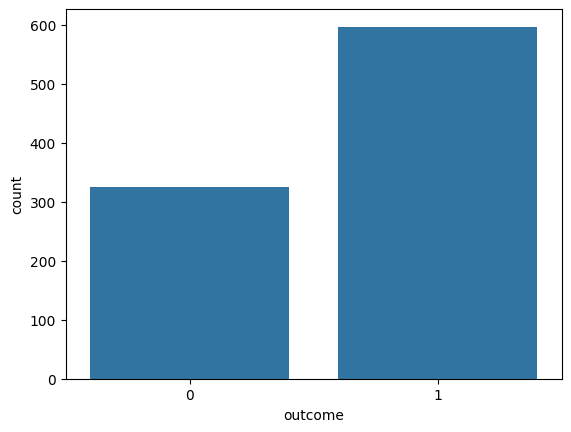

In [19]:
display(df.describe())
sns.countplot(x='outcome', data=df)
plt.show()


In [20]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_dev_arr = X_dev.values

print(f"Dev  : {X_dev.shape[0]}  Test : {X_test.shape[0]}")
print(f"Test class balance — Closed: {(y_test==0).sum()}  Acquired: {(y_test==1).sum()}")


Dev  : 738  Test : 185
Test class balance — Closed: 65  Acquired: 120


In [21]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def add_cluster_ohe(X_scaled, clusters, n_clusters=N_CLUSTERS):
    ohe = np.zeros((len(clusters), n_clusters))
    for i, c in enumerate(clusters):
        ohe[i, c] = 1
    return np.hstack([X_scaled, ohe])

baseline_models = {
    'LogReg' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM'    : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'MLP'    : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                              early_stopping=True, random_state=RANDOM_STATE),
}

hybrid_models = {
    'LR + KMeans'  : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM + KMeans' : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'MLP + KMeans' : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                                    early_stopping=True, random_state=RANDOM_STATE),
}


In [22]:
cv_results = {name: {'f1': [], 'auc': []} for name in list(baseline_models) + list(hybrid_models)}

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev_arr, y_dev)):
    print(f"--- Fold {fold+1}/{N_FOLDS} ---")

    X_tr, X_val = X_dev_arr[train_idx], X_dev_arr[val_idx]
    y_tr, y_val = y_dev[train_idx],     y_dev[val_idx]

    scaler       = StandardScaler()
    X_tr_scaled  = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    for name, template in baseline_models.items():
        model  = clone(template)
        model.fit(X_tr_scaled, y_tr)
        y_pred = model.predict(X_val_scaled)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
        cv_results[name]['f1'].append(f1_score(y_val, y_pred, average='macro'))
        cv_results[name]['auc'].append(roc_auc_score(y_val, y_prob))
        print(f"  {name:<15} F1={cv_results[name]['f1'][-1]:.3f}  AUC={cv_results[name]['auc'][-1]:.3f}")

    km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_tr_scaled)
    X_tr_hybrid  = add_cluster_ohe(X_tr_scaled,  km.predict(X_tr_scaled))
    X_val_hybrid = add_cluster_ohe(X_val_scaled, km.predict(X_val_scaled))

    for name, template in hybrid_models.items():
        model  = clone(template)
        model.fit(X_tr_hybrid, y_tr)
        y_pred = model.predict(X_val_hybrid)
        y_prob = model.predict_proba(X_val_hybrid)[:, 1]
        cv_results[name]['f1'].append(f1_score(y_val, y_pred, average='macro'))
        cv_results[name]['auc'].append(roc_auc_score(y_val, y_prob))
        print(f"  {name:<15} F1={cv_results[name]['f1'][-1]:.3f}  AUC={cv_results[name]['auc'][-1]:.3f}")


--- Fold 1/5 ---
  LogReg          F1=0.716  AUC=0.741
  SVM             F1=0.681  AUC=0.784
  MLP             F1=0.646  AUC=0.682
  LR + KMeans     F1=0.710  AUC=0.738
  SVM + KMeans    F1=0.681  AUC=0.782
  MLP + KMeans    F1=0.678  AUC=0.724
--- Fold 2/5 ---
  LogReg          F1=0.752  AUC=0.813
  SVM             F1=0.735  AUC=0.798
  MLP             F1=0.754  AUC=0.815
  LR + KMeans     F1=0.738  AUC=0.822
  SVM + KMeans    F1=0.738  AUC=0.797
  MLP + KMeans    F1=0.725  AUC=0.792
--- Fold 3/5 ---
  LogReg          F1=0.682  AUC=0.751
  SVM             F1=0.684  AUC=0.725
  MLP             F1=0.663  AUC=0.720
  LR + KMeans     F1=0.701  AUC=0.758
  SVM + KMeans    F1=0.690  AUC=0.729
  MLP + KMeans    F1=0.615  AUC=0.767
--- Fold 4/5 ---
  LogReg          F1=0.734  AUC=0.835
  SVM             F1=0.740  AUC=0.811
  MLP             F1=0.634  AUC=0.724
  LR + KMeans     F1=0.740  AUC=0.854
  SVM + KMeans    F1=0.740  AUC=0.813
  MLP + KMeans    F1=0.760  AUC=0.826
--- Fold 5/5 ---
  L

In [23]:
print(f"{'Model':<20} {'F1 Mean':>10} {'F1 Std':>10} {'AUC Mean':>10} {'AUC Std':>10}")
print("=" * 65)

cv_summary = {}
for name, scores in cv_results.items():
    f1_mean  = np.mean(scores['f1'])
    f1_std   = np.std(scores['f1'])
    auc_mean = np.mean(scores['auc'])
    auc_std  = np.std(scores['auc'])
    cv_summary[name] = dict(f1_mean=f1_mean, f1_std=f1_std,
                             auc_mean=auc_mean, auc_std=auc_std)
    print(f"{name:<20} {f1_mean:>10.3f} {f1_std:>10.3f} {auc_mean:>10.3f} {auc_std:>10.3f}")


Model                   F1 Mean     F1 Std   AUC Mean    AUC Std
LogReg                    0.707      0.037      0.775      0.041
SVM                       0.707      0.025      0.774      0.031
MLP                       0.671      0.043      0.729      0.045
LR + KMeans               0.706      0.036      0.779      0.051
SVM + KMeans              0.707      0.026      0.774      0.031
MLP + KMeans              0.698      0.049      0.769      0.037


/var/folders/rk/fpq7918x15x2cn5r3v6cg5400000gn/T/ipykernel_26052/2279689114.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha='right')
/var/folders/rk/fpq7918x15x2cn5r3v6cg5400000gn/T/ipykernel_26052/2279689114.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha='right')


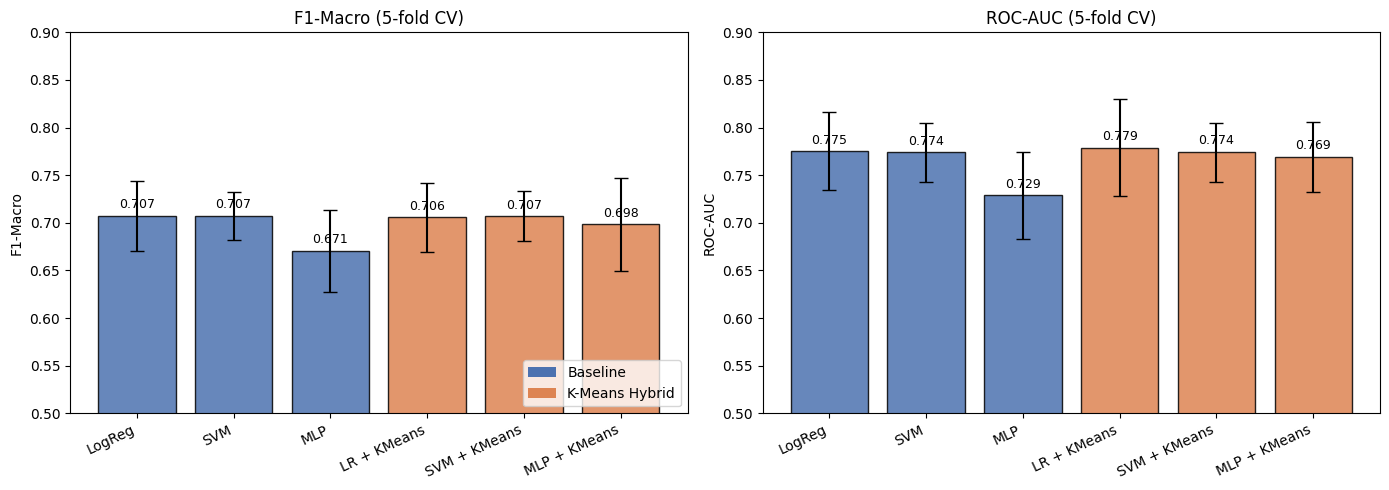

In [24]:
model_names = list(cv_results.keys())
f1_means  = [cv_summary[n]['f1_mean']  for n in model_names]
f1_stds   = [cv_summary[n]['f1_std']   for n in model_names]
auc_means = [cv_summary[n]['auc_mean'] for n in model_names]
auc_stds  = [cv_summary[n]['auc_std']  for n in model_names]
colors    = ['#4C72B0'] * 3 + ['#DD8452'] * 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, means, stds, title, ylabel in [
    (axes[0], f1_means,  f1_stds,  'F1-Macro (5-fold CV)',  'F1-Macro'),
    (axes[1], auc_means, auc_stds, 'ROC-AUC (5-fold CV)',   'ROC-AUC'),
]:
    bars = ax.bar(model_names, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, edgecolor='black')
    ax.set_ylim(0.5, 0.9)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(model_names, rotation=25, ha='right')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

legend_elements = [Patch(facecolor='#4C72B0', label='Baseline'),
                   Patch(facecolor='#DD8452', label='K-Means Hybrid')]
axes[0].legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()


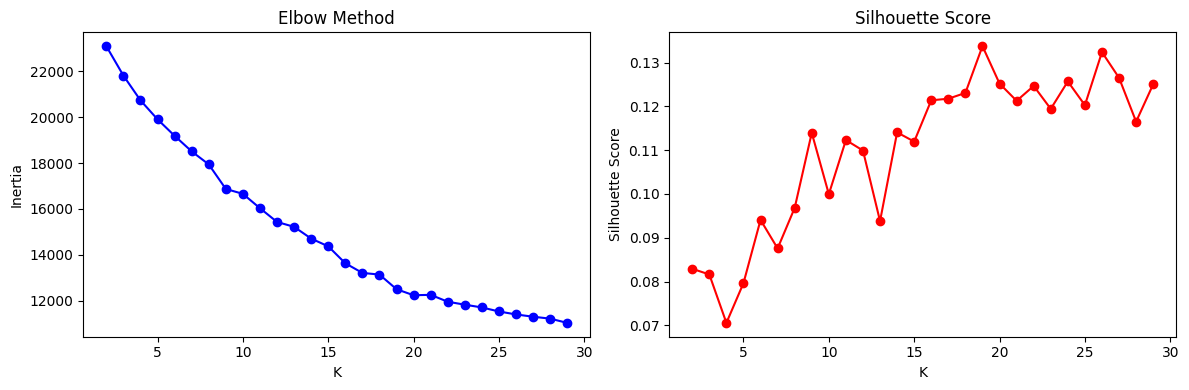

In [25]:
# Fit on full dev set for cluster analysis
_scaler_tmp = StandardScaler()
_X_dev_scaled_tmp = _scaler_tmp.fit_transform(X_dev_arr)

inertias    = []
silhouettes = []
K_range     = range(2, 30)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(_X_dev_scaled_tmp)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(_X_dev_scaled_tmp, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.show()



── LogReg ──
              precision    recall  f1-score   support

      Closed       0.69      0.65      0.67        65
    Acquired       0.81      0.84      0.83       120

    accuracy                           0.77       185
   macro avg       0.75      0.74      0.75       185
weighted avg       0.77      0.77      0.77       185

F1 Macro : 0.7473
ROC-AUC  : 0.8190


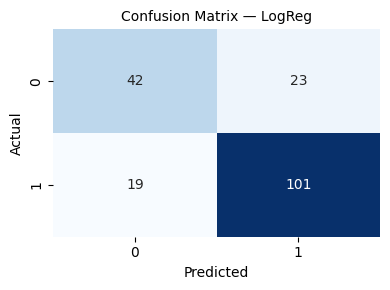


── SVM ──
              precision    recall  f1-score   support

      Closed       0.74      0.49      0.59        65
    Acquired       0.77      0.91      0.83       120

    accuracy                           0.76       185
   macro avg       0.76      0.70      0.71       185
weighted avg       0.76      0.76      0.75       185

F1 Macro : 0.7123
ROC-AUC  : 0.7964


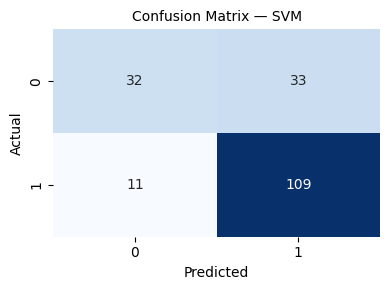


── MLP ──
              precision    recall  f1-score   support

      Closed       0.74      0.35      0.48        65
    Acquired       0.73      0.93      0.82       120

    accuracy                           0.73       185
   macro avg       0.73      0.64      0.65       185
weighted avg       0.73      0.73      0.70       185

F1 Macro : 0.6483
ROC-AUC  : 0.8033


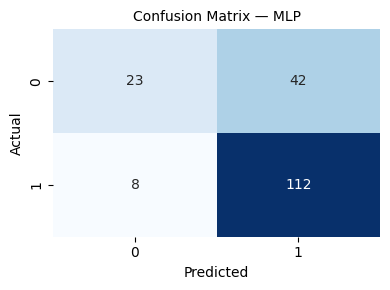


── LR + KMeans ──
              precision    recall  f1-score   support

      Closed       0.68      0.63      0.66        65
    Acquired       0.81      0.84      0.82       120

    accuracy                           0.77       185
   macro avg       0.75      0.74      0.74       185
weighted avg       0.76      0.77      0.77       185

F1 Macro : 0.7402
ROC-AUC  : 0.8132


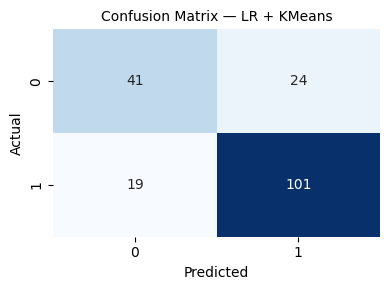


── SVM + KMeans ──
              precision    recall  f1-score   support

      Closed       0.71      0.46      0.56        65
    Acquired       0.76      0.90      0.82       120

    accuracy                           0.75       185
   macro avg       0.73      0.68      0.69       185
weighted avg       0.74      0.75      0.73       185

F1 Macro : 0.6910
ROC-AUC  : 0.7992


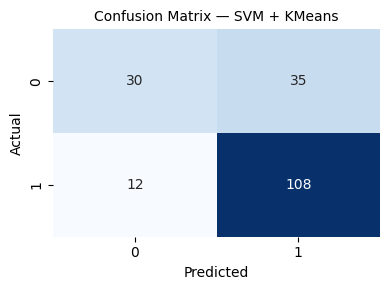


── MLP + KMeans ──
              precision    recall  f1-score   support

      Closed       0.84      0.42      0.56        65
    Acquired       0.75      0.96      0.84       120

    accuracy                           0.77       185
   macro avg       0.80      0.69      0.70       185
weighted avg       0.78      0.77      0.74       185

F1 Macro : 0.6996
ROC-AUC  : 0.8017


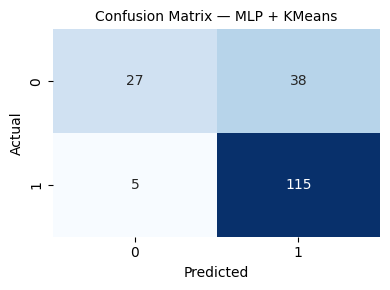

In [26]:
final_scaler  = StandardScaler()
X_dev_scaled  = final_scaler.fit_transform(X_dev_arr)
X_test_scaled = final_scaler.transform(X_test.values)

final_km      = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
final_km.fit(X_dev_scaled)

X_dev_hybrid  = add_cluster_ohe(X_dev_scaled,  final_km.predict(X_dev_scaled))
X_test_hybrid = add_cluster_ohe(X_test_scaled, final_km.predict(X_test_scaled))

all_final_models = {
    'LogReg'       : (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                      X_dev_scaled,  X_test_scaled),
    'SVM'          : (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
                      X_dev_scaled,  X_test_scaled),
    'MLP'          : (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                                    early_stopping=True, random_state=RANDOM_STATE),
                      X_dev_scaled,  X_test_scaled),
    'LR + KMeans'  : (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                      X_dev_hybrid,  X_test_hybrid),
    'SVM + KMeans' : (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
                      X_dev_hybrid,  X_test_hybrid),
    'MLP + KMeans' : (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                                    early_stopping=True, random_state=RANDOM_STATE),
                      X_dev_hybrid,  X_test_hybrid),
}

for name, (model, X_tr_, X_te_) in all_final_models.items():
    model.fit(X_tr_, y_dev)
    y_pred = model.predict(X_te_)
    y_prob = model.predict_proba(X_te_)[:, 1]

    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['Closed', 'Acquired']))
    print(f"F1 Macro : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

    fig, ax = plt.subplots(figsize=(4, 3))
    confusion = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=10)
    plt.tight_layout()
    plt.show()


In [27]:
# Cluster sizes
unique, counts = np.unique(final_km.predict(X_dev_scaled), return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} ({count/len(X_dev_scaled)*100:.1f}%)")


Cluster 0: 149 (20.2%)
Cluster 1: 84 (11.4%)
Cluster 2: 104 (14.1%)
Cluster 3: 63 (8.5%)
Cluster 4: 232 (31.4%)
Cluster 5: 106 (14.4%)


In [28]:
# Centroid values in original scale
feature_names     = X_dev.columns.tolist()
centroids_df      = pd.DataFrame(
    final_scaler.inverse_transform(final_km.cluster_centers_),
    columns=feature_names
)
display(centroids_df.round(2))


,latitude,longitude,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,...,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,has_milestone
0,37.03,-113.79,3.65,6.93,5.93,7.57,11.50,3.29,78057751.42,2.03,...,0.38,0.48,0.07,0.46,0.62,0.62,0.33,3.32,0.95,1.00
1,40.64,-75.45,1.16,2.46,2.01,3.54,8.83,2.20,11232162.38,2.29,...,0.27,0.20,0.45,0.55,0.29,0.15,0.04,3.25,0.76,0.92
2,41.36,-92.01,1.71,2.62,1.74,3.15,4.95,1.90,14021201.39,1.85,...,0.30,0.32,0.42,0.37,0.26,0.05,0.00,2.01,0.61,0.93
3,42.53,-71.02,2.41,5.13,3.28,4.71,8.38,2.71,24890556.83,1.97,...,0.27,0.37,0.14,0.59,0.56,0.41,0.16,2.90,0.90,0.87
4,36.61,-118.49,1.34,2.38,2.12,3.93,7.97,1.91,9508174.50,2.29,...,0.27,0.16,0.33,0.67,0.35,0.06,-0.00,2.70,0.80,1.00
5,37.01,-106.68,3.62,4.91,-0.05,-0.05,3.07,2.08,18630861.75,0.06,...,0.49,0.44,0.12,0.38,0.30,0.24,0.09,2.77,0.75,0.06


In [29]:
# ANOVA: which features differ significantly across clusters
cluster_labels = final_km.predict(X_dev_scaled)

print(f"{'Feature':<35} {'F-stat':>10} {'p-value':>12}")
print("-" * 60)

anova_results = []
for feature in feature_names:
    groups = [X_dev[feature].values[cluster_labels == k] for k in range(N_CLUSTERS)]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results.append((feature, f_stat, p_val))

anova_results.sort(key=lambda x: x[1], reverse=True)
for feature, f_stat, p_val in anova_results:
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{feature:<35} {f_stat:>10.2f} {p_val:>12.4f}  {sig}")


Feature                                 F-stat      p-value
------------------------------------------------------------
is_MA                                  8301.95       0.0000  ***
is_NY                                  3655.02       0.0000  ***
has_milestone                           436.18       0.0000  ***
is_otherstate                           244.32       0.0000  ***
is_CA                                   225.35       0.0000  ***
longitude                               195.62       0.0000  ***
age_last_milestone_year                 110.55       0.0000  ***
age_first_milestone_year                 90.79       0.0000  ***
age_last_funding_year                    83.25       0.0000  ***
latitude                                 78.02       0.0000  ***
milestones                               71.91       0.0000  ***
has_roundC                               53.35       0.0000  ***
has_roundD                               32.24       0.0000  ***
age_first_funding_year            

In [ ]:
# Outcome distribution per cluster
dev_copy = X_dev.copy()
dev_copy['cluster'] = cluster_labels
dev_copy['outcome'] = y_dev

outcome_dist = (dev_copy.groupby('cluster')['outcome']
                        .value_counts(normalize=True)
                        .unstack()
                        .rename(columns={0: 'Negative', 1: 'Positive'}))
print(outcome_dist.round(3))

outcome_dist.plot(kind='bar', figsize=(7, 4), colormap='Set2')
plt.title('Outcome Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()
